In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from pylab import rcParams
import networkx as nx
from scipy.integrate import trapz, simps 

In [26]:
G = nx.Graph()
G.add_edges_from([(1,2), (1, 3), (1, 4), (1, 5),(1,6), (2, 3), (2, 4),(2, 5), (2,6) ,(2,7) ,(2,8) , (6, 7), (6, 8), (6, 9),(7,9) ,(8,9),(8,10),(9,10)  ])

list_A = [2,9]
list_A1 = [2]
list_A2 = [9]


list_B = [1,3,4,5,6,7,8,10]


color = []
for i in G.nodes():
    if i in list_A1:
        col = 'red'
    elif i in list_A2:
        col = 'red'

    
    else:
        col = 'skyblue'
    color.append(col)

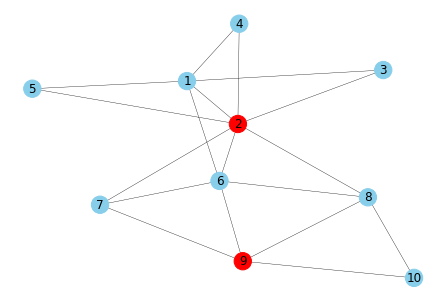

In [43]:
pos = nx.kamada_kawai_layout(G)

nx.draw(G,node_color=color,pos=pos ,node_size=300,width=0.35, with_labels=True)

# A:

apm 151.246.8.95_gk_model2 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.0
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :           22
   Intermediates:            0
   Connections  :            0
   Equations    :           21
   Residuals    :           21
 
 Number of state variables:          14925
 Number of total equations: -        12736
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :           2189
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program contains Ipopt

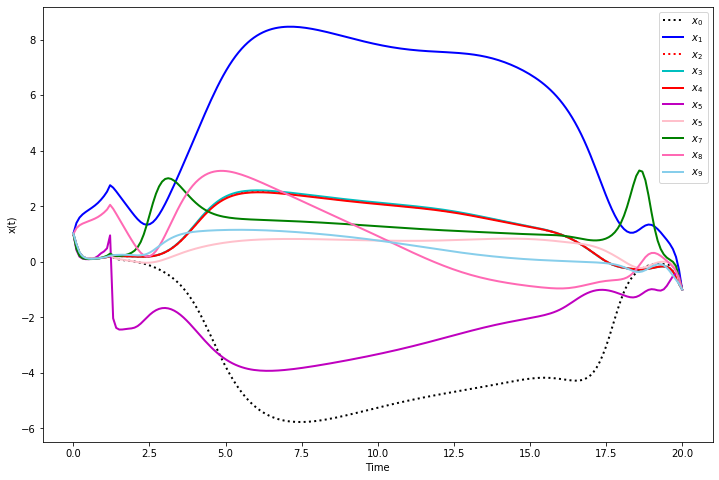

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from gekko import GEKKO

m = GEKKO()

#nt = 201
#m.time = np.linspace(0,10,nt)


# Set time
startt = 0.0 # select start time of the simulation
endt = 20.0 # select end time of the simulation
dt = 200 # select discretization of the simulation
m.time = np.linspace(startt, endt, dt) # set the time (from start to endt in dt steps)
finalt = int(dt*endt/(endt-startt))-1 # compute the discretization step belonging to the goalt
nt = dt

# Parameters
u21 = m.MV(value=1)
u21.STATUS = 1
u21.DCOST = 0

u23 = m.MV(value=1)
u23.STATUS = 1
u23.DCOST = 0

u24 = m.MV(value=1)
u24.STATUS = 1
u24.DCOST = 0

u25 = m.MV(value=1)
u25.STATUS = 1
u25.DCOST = 0

u26 = m.MV(value=1)
u26.STATUS = 1
u26.DCOST = 0

u27 = m.MV(value=1)
u27.STATUS = 1
u27.DCOST = 0

u28 = m.MV(value=1)
u28.STATUS = 1
u28.DCOST = 0

u96 = m.MV(value=1)
u96.STATUS = 1
u96.DCOST = 0

u97 = m.MV(value=1)
u97.STATUS = 1
u97.DCOST = 0

u98 = m.MV(value=1)
u98.STATUS = 1
u98.DCOST = 0

u910 = m.MV(value=1)
u910.STATUS = 1
u910.DCOST = 0

mu, sigma = 0, 0.01 # mean and standard deviation
s = np.random.normal(mu, sigma, 1)


# Variables
x1 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x2 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x3 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x4 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x5 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x6 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x7 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x8 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x9 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x10 = m.Var(value=1+np.random.normal(0, 0.01, 1))

p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Equations
m.Equation(x1.dt()== x2+x3+x4+x5+x6 + u21*x1)
m.Equation(x2.dt()== x1+x3+x4+x5+x6+x7+x8)
m.Equation(x3.dt()== x1+x2+ (u23)*x3)
m.Equation(x4.dt()== x1+x2 + u24*x4)
m.Equation(x5.dt()== x1+x2 +u25*x5)
m.Equation(x6.dt()== x1+x2+x7+x8+x9 + (u26 + u96)*x6)
m.Equation(x7.dt()== x2+x6+x9 + (u27+u97)*x7)
m.Equation(x8.dt()== x2+x9+x6+x10+ (u98+u28)*x8)
m.Equation(x9.dt()== x6 +x7+x8+x10 )
m.Equation(x10.dt()== x8+x9 + u910*x10)


m.Minimize(final*(x1+1)**2)
m.Minimize(final*(x2+1)**2)
m.Minimize(final*(x3+1)**2)
m.Minimize(final*(x4+1)**2)
m.Minimize(final*(x5+1)**2)
m.Minimize(final*(x6+1)**2)
m.Minimize(final*(x7+1)**2)
m.Minimize(final*(x8+1)**2)
m.Minimize(final*(x9+1)**2)
m.Minimize(final*(x10+1)**2)

# Objective Function
m.Obj(final*((u21**2+u23**2+u24**2 +u25**2+u26**2 +u27**2+u28**2+u96**2 +u97**2+u98**2+u910**2)-0.5*(x1**2+x2**2+x3**2+x4**2+x5**2+x6**2+x7**2+x8**2+x9**2+x10**2) + 0.25*(x1**4 + x2**4 + x3**4 + x4**4 + x5**4 + x6**4 + x7**4 + x8**4 + x9**4 + x10**4 )))

m.options.IMODE = 6
m.solve()

"""

u1 = np.array(u21.value)
u2 = np.array(u23.value)
u3 = np.array(u24.value)
u4 = np.array(u25.value)
u5 = np.array(u26.value)
u6 = np.array(u27.value)
u7 = np.array(u28.value)
u8 = np.array(u96.value)
u9 = np.array(u97.value)
u10 = np.array(u98.value)
u11 = np.array(u910.value)

"""

plt.figure(figsize=(12,8)) 
#plt.plot(m.time,((u1**2+u2**2+u3**2+u4**2+u5**2+u6**2+u7**2+u8**2+u9**2+u10**2)) )


plt.plot(m.time,x1.value,'k:',LineWidth=2,label=r'$x_1$')
plt.plot(m.time,x2.value,'blue',LineWidth=2,label=r'$x_2$')
plt.plot(m.time,x3.value,'r:',LineWidth=2,label=r'$x_3$')
plt.plot(m.time,x4.value,'c-',LineWidth=2,label=r'$x_4$')
plt.plot(m.time,x5.value,'red',LineWidth=2,label=r'$x_5$')
plt.plot(m.time,x6.value,'m-',LineWidth=2,label=r'$x_6$')
plt.plot(m.time,x7.value,'pink',LineWidth=2,label=r'$x_7$')
plt.plot(m.time,x8.value,'green',LineWidth=2,label=r'$x_8$')
plt.plot(m.time,x9.value,'hotpink',LineWidth=2,label=r'$x_9$')
plt.plot(m.time,x10.value,'skyblue',LineWidth=2,label=r'$x_10$')

plt.ylabel('x(t)')
plt.legend(loc='best')
plt.xlabel('Time')
#plt.savefig("optimalx(MDS)2.pdf")
"""

plt.figure(figsize=(12,8)) 
plt.subplot(3,1,1)
plt.plot(m.time,u21.value,'r-',LineWidth=2,label=r'$u1^0$')
plt.plot(m.time,u210.value,'b-',LineWidth=2,label=r'$u1^{9}$')
plt.plot(m.time,u23.value,'k-',LineWidth=2,label=r'$u1^2$')
plt.ylabel('u')
plt.legend(loc='best')

plt.subplot(3,1,2)
plt.plot(m.time,u53.value,'r-',LineWidth=2,label=r'$u4^2$')
plt.plot(m.time,u54.value,'b-',LineWidth=2,label=r'$u4^3$')
plt.plot(m.time,u56.value,'m-',LineWidth=2,label=r'$u4^5$')
plt.plot(m.time,u57.value,'c-',LineWidth=2,label=r'$u4^6$')
plt.plot(m.time,u59.value,'k-',LineWidth=2,label=r'$u4^8$')
plt.ylabel('u')
plt.legend(loc='best')

plt.subplot(3,1,3)
plt.plot(m.time,u87.value,'r-',LineWidth=2,label=r'$u7^6$')
plt.plot(m.time,u89.value,'b-',LineWidth=2,label=r'$u7^8$')

plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('u')
plt.savefig("optimalu.pdf")


plt.xlabel('Time')
#plt.ylabel('cost function')
#plt.savefig("cost function.pdf")
"""
plt.show()



Text(0, 0.5, 'Energy')

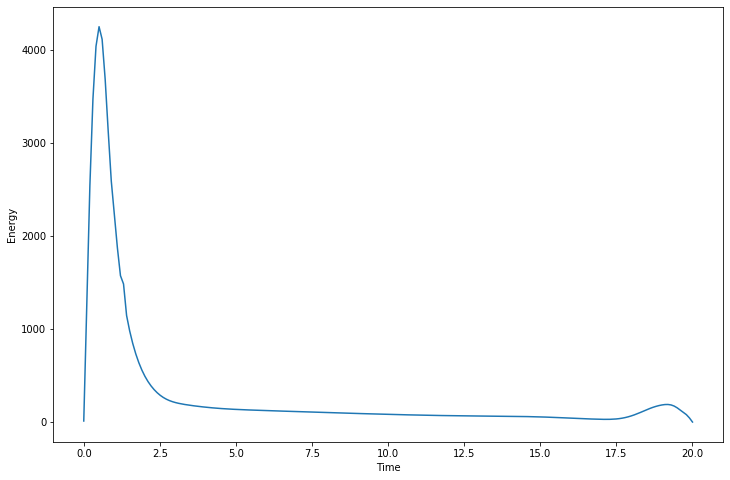

In [47]:
u1 = np.array(u21.value)
u2 = np.array(u23.value)
u3 = np.array(u24.value)
u4 = np.array(u25.value)
u5 = np.array(u26.value)
u6 = np.array(u27.value)
u7 = np.array(u28.value)
u8 = np.array(u96.value)
u9 = np.array(u97.value)
u10 = np.array(u98.value)
u11 = np.array(u910.value)


E = u1**2+u2**2+u3**2+u4**2 + u5**2 + u6**2+u7**2+u8**2+u9**2+u10**2+u11**2
plt.figure(figsize=(12,8)) 
plt.plot(m.time,((u1**2+u2**2+u3**2+u4**2 + u5**2 + u6**2+u7**2+u8**2+u9**2+u10**2+u11**2)) )

plt.xlabel("Time")           
plt.ylabel("Energy")
#plt.savefig("Energy1.pdf")

# B:

apm 151.246.8.95_gk_model3 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.0
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :           20
   Intermediates:            0
   Connections  :            0
   Equations    :           21
   Residuals    :           21
 
 Number of state variables:          12935
 Number of total equations: -        11144
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :           1791
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program contains Ipopt

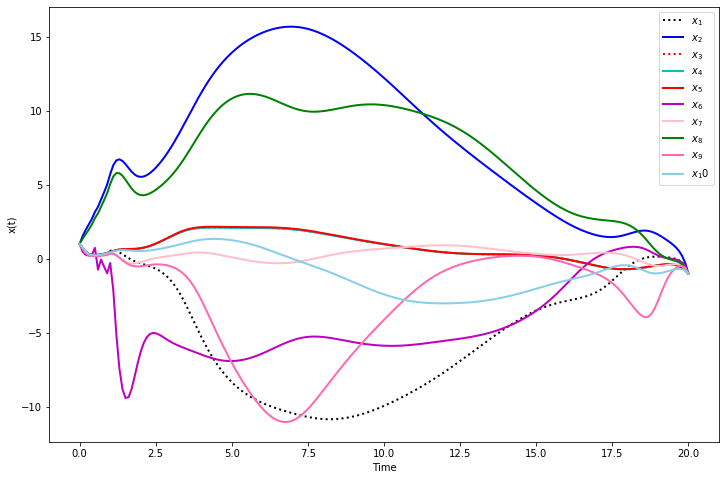

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from gekko import GEKKO

m = GEKKO()

#nt = 201
#m.time = np.linspace(0,10,nt)


# Set time
startt = 0.0 # select start time of the simulation
endt = 20.0 # select end time of the simulation
dt = 200 # select discretization of the simulation
m.time = np.linspace(startt, endt, dt) # set the time (from start to endt in dt steps)
finalt = int(dt*endt/(endt-startt))-1 # compute the discretization step belonging to the goalt
nt = dt

# Parameters
u21 = m.MV(value=1)
u21.STATUS = 1
u21.DCOST = 0

u23 = m.MV(value=1)
u23.STATUS = 1
u23.DCOST = 0

u24 = m.MV(value=1)
u24.STATUS = 1
u24.DCOST = 0

u25 = m.MV(value=1)
u25.STATUS = 1
u25.DCOST = 0

u26 = m.MV(value=1)
u26.STATUS = 1
u26.DCOST = 0

u27 = m.MV(value=1)
u27.STATUS = 1
u27.DCOST = 0

u86 = m.MV(value=1)
u86.STATUS = 1
u86.DCOST = 0

u89 = m.MV(value=1)
u89.STATUS = 1
u89.DCOST = 0

u810 = m.MV(value=1)
u810.STATUS = 1
u810.DCOST = 0


mu, sigma = 0, 0.01 # mean and standard deviation
s = np.random.normal(mu, sigma, 1)


# Variables
x1 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x2 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x3 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x4 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x5 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x6 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x7 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x8 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x9 = m.Var(value=1+np.random.normal(0, 0.01, 1))
x10 = m.Var(value=1+np.random.normal(0, 0.01, 1))

p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Equations
m.Equation(x1.dt()== x2+x3+x4+x5+x6 + u21*x1)
m.Equation(x2.dt()== x1+x3+x4+x5+x6+x7+x8)
m.Equation(x3.dt()== x1+x2+ (u23)*x3)
m.Equation(x4.dt()== x1+x2 + u24*x4)
m.Equation(x5.dt()== x1+x2 +u25*x5)
m.Equation(x6.dt()== x1+x2+x7+x8+x9 + (u26 + u86)*x6)
m.Equation(x7.dt()== x2+x6+x9 + (u27)*x7)
m.Equation(x8.dt()== x2+x9+x6+x10)
m.Equation(x9.dt()== x6 +x7+x8+x10 + u89*x9)
m.Equation(x10.dt()== x8+x9 + u810*x10)


m.Minimize(final*(x1+1)**2)
m.Minimize(final*(x2+1)**2)
m.Minimize(final*(x3+1)**2)
m.Minimize(final*(x4+1)**2)
m.Minimize(final*(x5+1)**2)
m.Minimize(final*(x6+1)**2)
m.Minimize(final*(x7+1)**2)
m.Minimize(final*(x8+1)**2)
m.Minimize(final*(x9+1)**2)
m.Minimize(final*(x10+1)**2)

# Objective Function
m.Obj(final*((u21**2+u23**2+u24**2 +u25**2+u26**2 +u27**2+u86**2 +u89**2+u810**2)-0.5*(x1**2+x2**2+x3**2+x4**2+x5**2+x6**2+x7**2+x8**2+x9**2+x10**2) + 0.25*(x1**4 + x2**4 + x3**4 + x4**4 + x5**4 + x6**4 + x7**4 + x8**4 + x9**4 + x10**4 )))

m.options.IMODE = 6
m.solve()

"""

u1 = np.array(u21.value)
u2 = np.array(u23.value)
u3 = np.array(u24.value)
u4 = np.array(u25.value)
u5 = np.array(u26.value)
u6 = np.array(u27.value)
u7 = np.array(u28.value)
u8 = np.array(u86.value)
u9 = np.array(u89.value)
u10 = np.array(u810.value)

"""

plt.figure(figsize=(12,8)) 
#plt.plot(m.time,((u1**2+u2**2+u3**2+u4**2+u5**2+u6**2+u7**2+u8**2+u9**2+u10**2)) )


plt.plot(m.time,x1.value,'k:',LineWidth=2,label=r'$x_1$')
plt.plot(m.time,x2.value,'blue',LineWidth=2,label=r'$x_2$')
plt.plot(m.time,x3.value,'r:',LineWidth=2,label=r'$x_3$')
plt.plot(m.time,x4.value,'c-',LineWidth=2,label=r'$x_4$')
plt.plot(m.time,x5.value,'red',LineWidth=2,label=r'$x_5$')
plt.plot(m.time,x6.value,'m-',LineWidth=2,label=r'$x_6$')
plt.plot(m.time,x7.value,'pink',LineWidth=2,label=r'$x_7$')
plt.plot(m.time,x8.value,'green',LineWidth=2,label=r'$x_8$')
plt.plot(m.time,x9.value,'hotpink',LineWidth=2,label=r'$x_9$')
plt.plot(m.time,x10.value,'skyblue',LineWidth=2,label=r'$x_10$')

plt.ylabel('x(t)')
plt.legend(loc='best')
plt.xlabel('Time')
#plt.savefig("optimalx(MDS)2.pdf")
"""

plt.figure(figsize=(12,8)) 
plt.subplot(3,1,1)
plt.plot(m.time,u21.value,'r-',LineWidth=2,label=r'$u1^0$')
plt.plot(m.time,u210.value,'b-',LineWidth=2,label=r'$u1^{9}$')
plt.plot(m.time,u23.value,'k-',LineWidth=2,label=r'$u1^2$')
plt.ylabel('u')
plt.legend(loc='best')

plt.subplot(3,1,2)
plt.plot(m.time,u53.value,'r-',LineWidth=2,label=r'$u4^2$')
plt.plot(m.time,u54.value,'b-',LineWidth=2,label=r'$u4^3$')
plt.plot(m.time,u56.value,'m-',LineWidth=2,label=r'$u4^5$')
plt.plot(m.time,u57.value,'c-',LineWidth=2,label=r'$u4^6$')
plt.plot(m.time,u59.value,'k-',LineWidth=2,label=r'$u4^8$')
plt.ylabel('u')
plt.legend(loc='best')

plt.subplot(3,1,3)
plt.plot(m.time,u87.value,'r-',LineWidth=2,label=r'$u7^6$')
plt.plot(m.time,u89.value,'b-',LineWidth=2,label=r'$u7^8$')

plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('u')
plt.savefig("optimalu.pdf")


plt.xlabel('Time')
#plt.ylabel('cost function')
#plt.savefig("cost function.pdf")
"""
plt.show()




Text(0, 0.5, 'Energy')

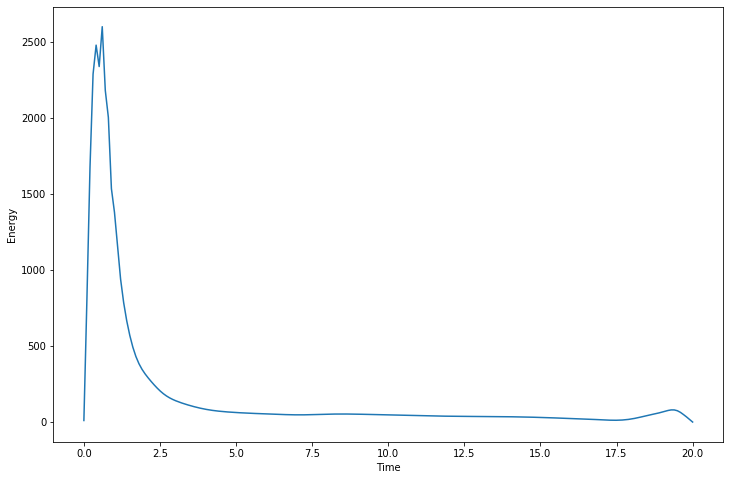

In [49]:
u1 = np.array(u21.value)
u2 = np.array(u23.value)
u3 = np.array(u24.value)
u4 = np.array(u25.value)
u5 = np.array(u26.value)
u6 = np.array(u27.value)
u7 = np.array(u28.value)
u8 = np.array(u86.value)
u9 = np.array(u89.value)
u10 = np.array(u810.value)

E = u1**2+u2**2+u3**2+u4**2 + u5**2 + u6**2+u7**2+u8**2+u9**2+u10**2
plt.figure(figsize=(12,8)) 
plt.plot(m.time,((u1**2+u2**2+u3**2+u4**2 + u5**2 + u6**2+u7**2+u8**2+u9**2+u10**2)) )

plt.xlabel("Time")           
plt.ylabel("Energy")
#plt.savefig("Energy1.pdf")